# Predicting heart disease using machine learning

Notebook content:
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## Problem Definition

> Given clinical parameters about a patient, can we predict wether or not they have heart disease?

## Data


This dataset contains various health indicators and risk factors related to heart disease. Parameters such as age, gender, blood pressure, cholesterol levels, smoking habits, and exercise patterns have been collected to analyze heart disease risk and contribute to health research. The dataset can be used by healthcare professionals, researchers, and data analysts to examine trends related to heart disease, identify risk factors, and perform various health-related analyses.

Origin: https://www.kaggle.com/datasets/oktayrdeki/heart-disease

## Evaluation

> If we can reach 95% accuracy at predicting wether or not a patient has heart disease during the proof of concept, weĺl pursue the project.

## Features

Columns:
* Age: The individual's age.
* Gender: The individual's gender (Male or Female).
* Blood Pressure: The individual's blood pressure (systolic).
* Cholesterol Level: The individual's total cholesterol level.
* Exercise Habits: The individual's exercise habits (Low, Medium, High).
* Smoking: Whether the individual smokes or not (Yes or No).
* Family Heart Disease: Whether there is a family history of heart disease (Yes or No).
* Diabetes: Whether the individual has diabetes (Yes or No).
* BMI: The individual's body mass index.
* High Blood Pressure: Whether the individual has high blood pressure (Yes or No).
* Low HDL Cholesterol: Whether the individual has low HDL cholesterol (Yes or No).
* High LDL Cholesterol: Whether the individual has high LDL cholesterol (Yes or No).
* Alcohol Consumption: The individual's alcohol consumption level (None, Low, Medium, High).
* Stress Level: The individual's stress level (Low, Medium, High).
* Sleep Hours: The number of hours the individual sleeps.
* Sugar Consumption: The individual's sugar consumption level (Low, Medium, High).
* Triglyceride Level: The individual's triglyceride level.
* Fasting Blood Sugar: The individual's fasting blood sugar level.
* CRP Level: The C-reactive protein level (a marker of inflammation).
* Homocysteine Level: The individual's homocysteine level (an amino acid that affects blood vessel health).
* Heart Disease Status: The individual's heart disease status (Yes or No).

## Preparing the tools

I'm using pandas, Matplotlib and NumPy to analyse and manipule the data

In [32]:
# EDA (Exploratory Data Analysis)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Model Evaluations
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import RocCurveDisplay

## Load data

In [2]:
df = pd.read_csv("datasets/heart_disease.csv")
df.shape # (rows, columns)

(10000, 21)

## Data Preparation

In [3]:
df = df.dropna()

In [4]:
df = df.replace({
    "Male": 1,
    "Female": 0,
    
    "Yes": 1,
    "No": 0,

    "Low": 0,
    "Medium": 1,
    "High": 2
})

In [5]:
df["Heart Disease Status"] = df["Heart Disease Status"].astype(int)

print(df["Heart Disease Status"].unique())
print(df["Heart Disease Status"].dtype)

[0 1]
int64


## Data Exploration

In [6]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
1,69.0,0,146.0,286.0,2,0,1,1,25.221799,0,...,0,1,2,8.744034,1,133.0,157.0,9.355389,19.298875,0
2,46.0,1,126.0,216.0,0,0,0,0,29.855447,0,...,1,0,0,4.440440,0,393.0,92.0,12.709873,11.230926,0
3,32.0,0,122.0,293.0,2,1,1,0,24.130477,1,...,1,0,2,5.249405,2,293.0,94.0,12.509046,5.961958,0
4,60.0,1,166.0,242.0,0,1,1,1,20.486289,1,...,0,0,2,7.030971,2,263.0,154.0,10.381259,8.153887,0
5,25.0,1,152.0,257.0,0,1,0,0,28.144681,0,...,0,0,1,5.504876,0,126.0,91.0,4.297575,10.815983,0


In [7]:
df.shape

(7067, 21)

In [8]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
count,7067.000000,7067.000000,7067.000000,7067.000000,7067.000000,7067.000000,7067.000000,7067.000000,7067.000000,7067.000000
mean,49.301542,149.856092,224.722938,29.023933,6.982595,250.523136,119.966605,7.448118,12.444451,0.203056
std,18.270030,17.606064,43.529500,6.276510,1.749378,87.051480,23.612628,4.358898,4.311619,0.402303
min,18.000000,120.000000,150.000000,18.007058,4.000605,100.000000,80.000000,0.010585,5.002810,0.000000
25%,34.000000,134.000000,187.000000,23.633185,5.459460,176.000000,99.000000,3.629919,8.723192,0.000000
50%,49.000000,150.000000,224.000000,29.046381,6.982377,250.000000,120.000000,7.445087,12.428130,0.000000
75%,65.000000,166.000000,262.000000,34.402934,8.519562,326.000000,141.000000,11.209659,16.100166,0.000000
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037,1.000000


In [27]:
df["Heart Disease Status"].value_counts()

Heart Disease Status
0    5632
1    1435
Name: count, dtype: int64

<Axes: xlabel='Heart Disease Status', ylabel='count'>

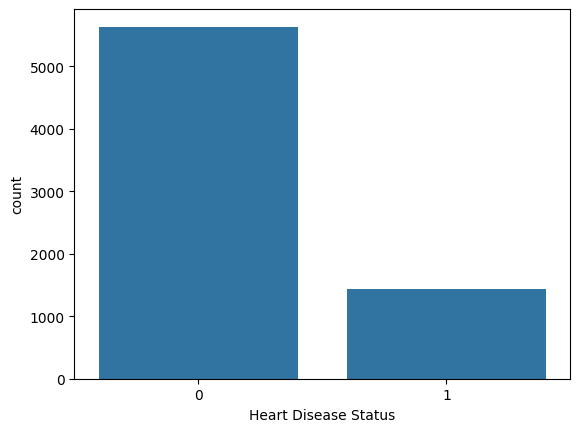

In [29]:
sns.countplot(x=df["Heart Disease Status"])

In [9]:
df["Gender"].value_counts()

Gender
1    3564
0    3503
Name: count, dtype: int64

In [10]:
df["Age"].mean()

np.float64(49.30154238007641)

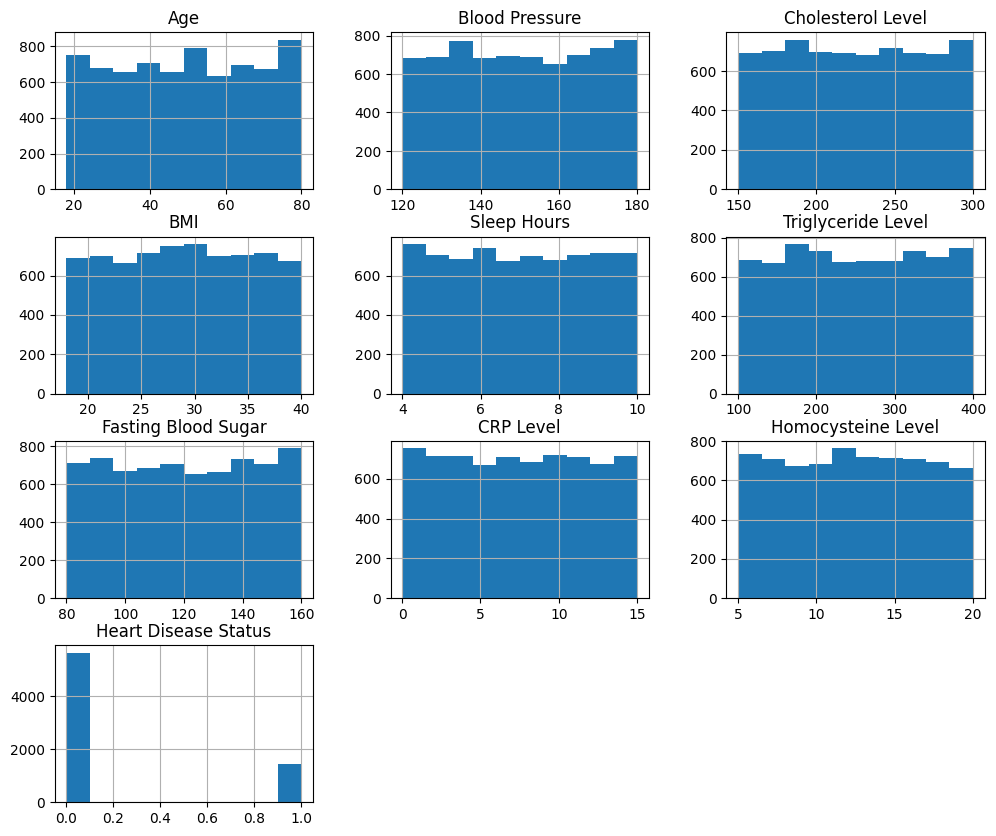

In [11]:
df.hist(figsize=(12, 10))
plt.show()

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

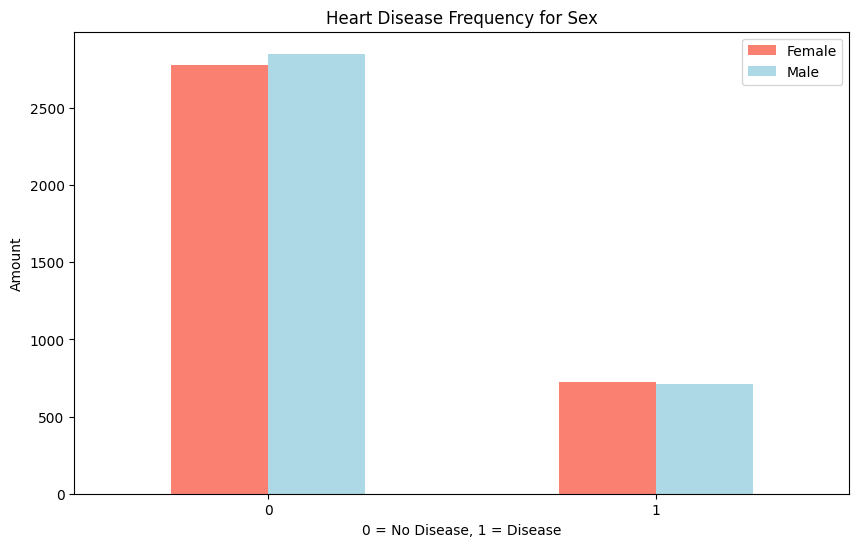

In [12]:
pd.crosstab(df["Heart Disease Status"], df["Gender"]).plot(
    kind="bar", 
    color=["salmon", "lightblue"], 
    figsize=(10,6)) 

plt.title("Heart Disease Frequency for Sex") 
plt.xlabel("0 = No Disease, 1 = Disease") 
plt.ylabel("Amount") 
plt.legend(["Female", "Male"]) 
plt.xticks(rotation=0)

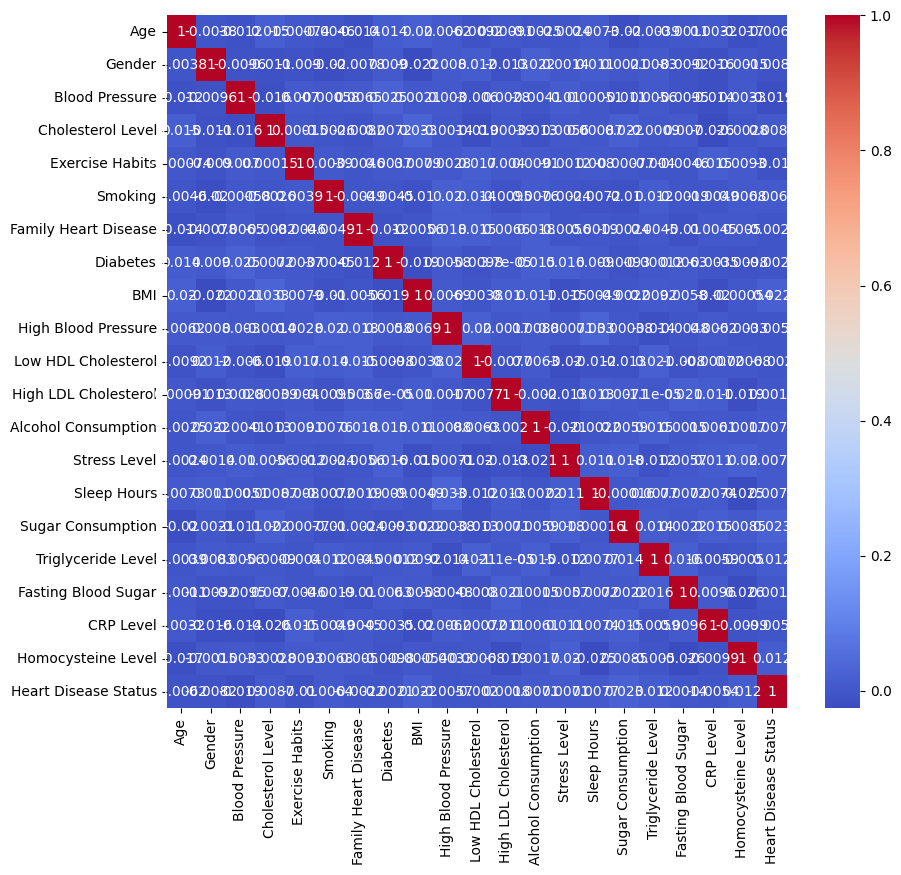

In [13]:
plt.figure(figsize=(10,9))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

<Axes: xlabel='Heart Disease Status', ylabel='Age'>

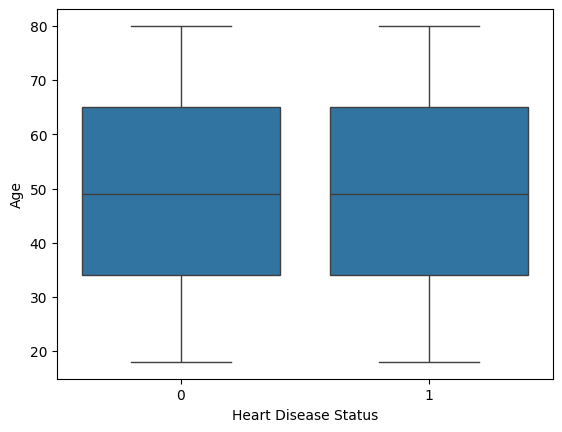

In [14]:
sns.boxplot(x="Heart Disease Status", y="Age", data=df)

<Axes: xlabel='Gender', ylabel='count'>

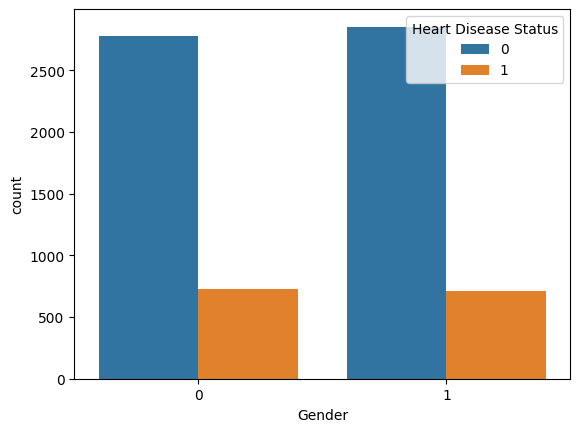

In [15]:
sns.countplot(x="Gender", hue="Heart Disease Status", data=df)

## Prepare Data

In [16]:
X = df.drop("Heart Disease Status", axis=1)
y = df["Heart Disease Status"]

## Normalize Data

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
1,69.0,0,146.0,286.0,2,0,1,1,25.221799,0,...,0,1,2,8.744034,1,133.0,157.0,9.355389,19.298875,0
2,46.0,1,126.0,216.0,0,0,0,0,29.855447,0,...,1,0,0,4.440440,0,393.0,92.0,12.709873,11.230926,0
3,32.0,0,122.0,293.0,2,1,1,0,24.130477,1,...,1,0,2,5.249405,2,293.0,94.0,12.509046,5.961958,0
4,60.0,1,166.0,242.0,0,1,1,1,20.486289,1,...,0,0,2,7.030971,2,263.0,154.0,10.381259,8.153887,0
5,25.0,1,152.0,257.0,0,1,0,0,28.144681,0,...,0,0,1,5.504876,0,126.0,91.0,4.297575,10.815983,0


## Split Data

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## Logistic Regression

In [30]:
# Model
model = LogisticRegression(class_weight="balanced", max_iter=1000)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
acc_score = accuracy_score(y_test, y_pred)

print("Accuracy Score:", acc_score)

Accuracy Score: 0.49646393210749645


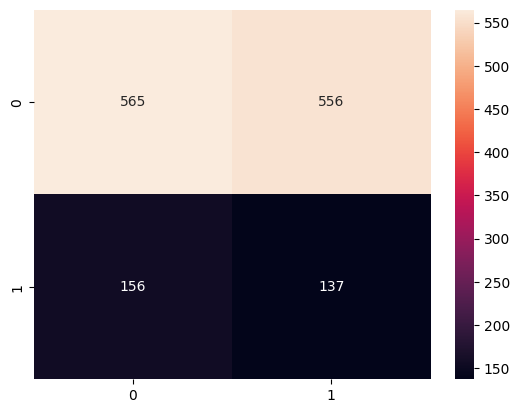

In [31]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()

## Test Different Models

In [52]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True)
}

In [62]:
def evaluate_models(models, X_train, X_test, y_train, y_test):

    results = {}

    for name, model in models.items():

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        results[name] = {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0)
        }

    return pd.DataFrame(results)

In [63]:
results = evaluate_models(models, X_train, X_test, y_train, y_test)

results

,Logistic Regression,KNN,Random Forest,Gradient Boosting,SVM
accuracy,0.496464,0.763791,0.792786,0.792786,0.792786
precision,0.197691,0.226667,0.000000,0.000000,0.000000
recall,0.467577,0.058020,0.000000,0.000000,0.000000
f1,0.277890,0.092391,0.000000,0.000000,0.000000


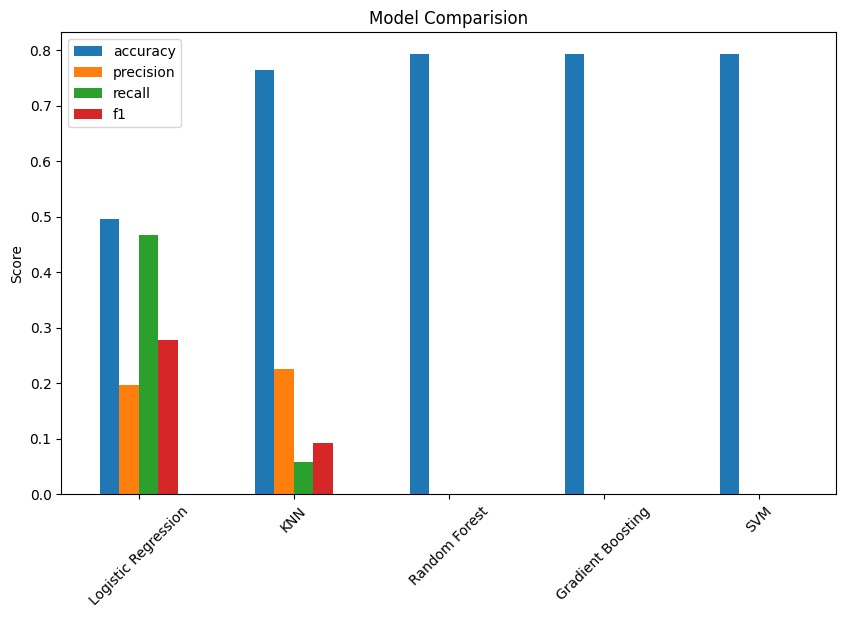

In [64]:
results.T.plot(kind="bar", figsize=(10,6))
plt.title("Model Comparision")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()